In [41]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set BCH-specific variables.

In [42]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity',
                'age_group']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                #             'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                # 'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                #   'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                #     'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                #     'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                #     'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                #     'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                #     'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                #     'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                                    'physician_or_hospital_referral'
                    ]


#Continuous predictors.
#NOTE: age enters the model only via the categorical 'age_group' bins above, not as a raw
#continuous 'age_in_days' predictor. Weight and HR/RR are age-normalised (see
#AGE_NORMALISED_VITALS / age_normalise_vitals below) so they're expressed relative to what's
#typical for that age group, rather than as raw values; the '_z' columns are created inside
#the modelling pipeline (cell 9), not in the raw data.
#SBP is likewise replaced with the PALS-criterion hypotension distance (0 if not hypotensive,
#else mmHg below the age-adjusted threshold) -- computed in cell 4, not a train-fit statistic
#like the '_z' columns, since it's a fixed clinical formula rather than something estimated
#from the data.
continuous_predictors = [
    'age_in_days',
    'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight_z', 'max_early_chews_score', #Leave out pseudo-nedocs
     'num_previous_admissions', 'num_previous_visits_without_admission',
    'max_hr_z',
    'max_pain',
    'max_rr_z',
    'max_hypotension_distance',
    'max_sp_o2',
    'mean_hr_z',
    'mean_pain',
    'mean_rr_z',
    'mean_hypotension_distance',
    'mean_sp_o2',
    'min_hr_z',
    'min_pain',
    'min_rr_z',
    'min_hypotension_distance',
    'min_sp_o2'
]




#-------AGE GROUPS (used as a categorical predictor instead of raw age_in_days)------------
DAYS_PER_MONTH = 30.4375   # 365.25 / 12, for unambiguous month cutoffs
DAYS_PER_YEAR = 365.25

AGE_BIN_EDGES_DAYS = [
    0,
    3 * DAYS_PER_MONTH,
    6 * DAYS_PER_MONTH,
    12 * DAYS_PER_MONTH,
    18 * DAYS_PER_MONTH,
    36 * DAYS_PER_MONTH,
    5 * DAYS_PER_YEAR,
    10 * DAYS_PER_YEAR,
    15 * DAYS_PER_YEAR,
    np.inf,
]
AGE_BIN_LABELS = [
    "0-3mo", "3-6mo", "6-12mo", "12-18mo", "18-36mo",
    "3-5y", "5-10y", "10-15y", "15+",
]
UNKNOWN_AGE_GROUP = "unknown"  # fallback bucket for missing/out-of-range ages


def assign_age_group(df: pd.DataFrame, age_col: str, age_group_col: str = "age_group") -> pd.DataFrame:
    """
    Adds an age_group categorical column from a numeric age_in_days column.
    Bins are left-inclusive/right-exclusive (e.g. "0-3mo" = [0, 3mo)).
    Missing or negative/invalid ages fall back to a shared "unknown" bucket
    rather than becoming NaN, so every row still has a usable group.
    """
    df = df.copy()
    age_days = df[age_col]
    group = pd.cut(age_days, bins=AGE_BIN_EDGES_DAYS, labels=AGE_BIN_LABELS,
                    right=False, include_lowest=True)
    df[age_group_col] = group.astype(object)
    df[age_group_col] = df[age_group_col].where(age_days.notna() & (age_days >= 0), UNKNOWN_AGE_GROUP)
    df[age_group_col] = df[age_group_col].fillna(UNKNOWN_AGE_GROUP)
    return df


#-------AGE-NORMALISED VITALS (expressed as SDs from the age group's mean)------------
#Weight and all HR/RR summary stats are age-normalised rather than used as raw values,
#since 'normal' ranges for these vary hugely with age. Blood pressure, SpO2, and pain
#are left as raw values. The '_z' columns referenced in continuous_predictors above are
#created from these by age_normalise_vitals() inside the modelling pipeline (cell 9).
AGE_NORMALISED_VITALS = ['raw_weight', 'max_hr', 'mean_hr', 'min_hr', 'max_rr', 'mean_rr', 'min_rr']


#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}




---LOAD FILES---

#Load in the pre-processed BCH data: pre-epic, with processed chief complaints and raw triage vitals; define outcomes.


In [43]:
#----LOAD RAW DATA------
visits = pd.read_csv(load_filepath + raw_file_name + ".csv", index_col=0, low_memory=False)

#-----EXTRACT ADMIT SOURCES----------
admit_sources = pd.read_csv(raw_filepath + "LaCava_Demopgraphics_May1_V1.csv", engine='pyarrow')[['CSN', 'ADMIT_SOURCE']].drop_duplicates().rename(
    columns={'CSN':'csn', 'ADMIT_SOURCE':'admit_source'}
)
admit_sources['physician_or_hospital_referral'] = admit_sources['admit_source'].isin(['Physician Referral', 'Hospital', 'Other Health Care Facility', 'Internal Transfer Med/Psych', 'Other Rehab Facility', 'Ambulatory Surgery Center'])
visits = visits.merge(admit_sources[['csn', 'physician_or_hospital_referral']], on='csn', how='left')
assert(visits['csn'].nunique() == len(visits))

#--------LOAD VITALS-------------
vitals = pd.read_csv(load_filepath + "intermediate-files/vitals-with-age-and-pain.csv", index_col=0, engine='pyarrow').rename(columns={
    'time_since_arrival':'timestamp',
    'measure': 'vital_type',
    'value':'vital_value'
})[['csn', 'arrival_time', 'vital_type', 'vital_value', 'age_in_days', 'timestamp']]
print("loaded vitals")

#Keep only vitals for included visits.
vitals = vitals.merge(visits[['csn']], on='csn', how='inner')

#Transform vitals to numeric.
vitals['vital_value'] = pd.to_numeric(vitals['vital_value'])



#-----LABEL VITAL OUTCOMES-------
# OUTCOME 1: Tachycardia definitions according to the ACLS:
vitals['tachycardia'] = ((vitals['vital_type']=='hr') & (
    ((vitals['age_in_days'] <= 120) & (vitals['vital_value'] >= 205)) | #Less than 4 months old, HR > 205 bpm
    ((vitals['age_in_days'] > 120) & (vitals['age_in_days'] <= 365.25*2) & (vitals['vital_value'] >= 190)) | #4 months to 2 years, HR > 190 bpm 
    ((vitals['age_in_days'] > 365.25*2) & (vitals['age_in_days'] <= 365.25*10) & (vitals['vital_value'] >= 140)) | #2-10 years, HR > 140 bpm
    ((vitals['age_in_days'] > 365.25*10) & (vitals['vital_value'] >= 100)))).astype(int) #Older than 10, HR > 100bpm
     

# OUTCOME 2a: Hypotension according to ACLS
vitals['hypotension'] = ((vitals['vital_type']=='sbp') & (
    ((vitals['age_in_days'] <= 4) & (vitals['vital_value'] < 60)) | #Up to 4 days old, SBP < 60
    ((vitals['age_in_days'] > 4) & (vitals['age_in_days'] <= 365.25/2) & (vitals['vital_value'] < 70)) | #4 days to 6 months, SBP < 70
    ((vitals['age_in_days'] > 365.25/2) & (vitals['age_in_days'] <= 365.25*14) & (vitals['vital_value'] < (70 + 2*np.floor(vitals['age_in_days']/365.25)))) | #6 months to 14 years, SBP < 70 + 2*age in years (rounded)
    ((vitals['age_in_days'] > 365.25*14) & (vitals['vital_value'] < 90)))).astype(int) #Older than 14, SBP < 90

#PALS-CRITERION HYPOTENSION DISTANCE (continuous predictor, not just a binary outcome flag).
#Same age-adjusted SBP thresholds as OUTCOME 2a above, but instead of a 0/1 flag we keep
#"how far below threshold" as a continuous score: 0 if not hypotensive by this criterion,
#otherwise the number of mmHg below the age-appropriate cutoff (so e.g. an SBP 2 mmHg below
#threshold scores 2, more severe hypotension scores higher). Used as a predictor -- see
#AGE_NORMALISED_VITALS / continuous_predictors in cell 2 -- so the model gets a graded signal
#rather than a hard threshold.
pals_sbp_threshold = np.select(
    [
        vitals['age_in_days'] <= 4,
        (vitals['age_in_days'] > 4) & (vitals['age_in_days'] <= 365.25/2),
        (vitals['age_in_days'] > 365.25/2) & (vitals['age_in_days'] <= 365.25*14),
        vitals['age_in_days'] > 365.25*14,
    ],
    [
        60,
        70,
        70 + 2*np.floor(vitals['age_in_days']/365.25),
        90,
    ],
    default=np.nan,
)
vitals['hypotension_distance'] = np.where(
    vitals['vital_type'] == 'sbp',
    np.clip(pals_sbp_threshold - vitals['vital_value'], a_min=0, a_max=None),
    np.nan
)

# OUTCOME 2b: Hypotension according to Anne (ACLS-5)
vitals['severe_hypotension'] = ((vitals['vital_type']=='sbp') & (
    ((vitals['age_in_days'] <= 4) & (vitals['vital_value'] < 55)) | #Up to 4 days old, SBP < 55
    ((vitals['age_in_days'] > 4) & (vitals['age_in_days'] <= 365.25/2) & (vitals['vital_value'] < 65)) | #4 days to 6 months, SBP < 65
    ((vitals['age_in_days'] > 365.25/2) & (vitals['age_in_days'] <= 365.25*14) & (vitals['vital_value'] < (65 + 2*np.floor(vitals['age_in_days']/365.25)))) | #6 months to 14 years, SBP < 65 + 2*age in years (rounded)
    ((vitals['age_in_days'] > 365.25*14) & (vitals['vital_value'] < 85)))).astype(int) #Older than 14, SBP < 85


#OUTCOME 3: Hypoxia (SpO2 < 90)
vitals['hypoxia'] = ((vitals['vital_type']=='sp_o2') & (vitals['vital_value'] < 85)).astype(int)


#-----GET VITALS IN FIRST 30 MINUTES------
early_vitals = vitals[vitals['timestamp'] <= 30].groupby(['csn', 'vital_type']).agg(
    max = ('vital_value', 'max'),
    mean = ('vital_value', 'mean'),
    min = ('vital_value', 'min')
).reset_index()

early_vitals = early_vitals.pivot_table(
    index = 'csn',
    columns = 'vital_type',
    values = ['max', 'mean', 'min']
).reset_index()

early_vitals.columns = [
    '_'.join(col).strip('_') if col[1] else col[0]
    for col in early_vitals.columns
]
visits = visits.merge(early_vitals, on='csn', how='left')

#----GET PALS HYPOTENSION DISTANCE IN FIRST 30 MINUTES-----
#Aggregated the same way as the raw vitals above (true min/max/mean of the per-reading
#distance, not the distance of the min/max/mean SBP -- these aren't the same thing, since
#the distance-from-threshold transform is nonlinear).
early_hypotension_distance = vitals[(vitals['timestamp'] <= 30) & (vitals['vital_type'] == 'sbp')].groupby('csn').agg(
    max_hypotension_distance = ('hypotension_distance', 'max'),
    mean_hypotension_distance = ('hypotension_distance', 'mean'),
    min_hypotension_distance = ('hypotension_distance', 'min'),
).reset_index()
visits = visits.merge(early_hypotension_distance, on='csn', how='left')

#----GET MAX CHEWS SCORE AND PAIN IN FIRST 30 MINUTES-----
scores = pd.read_csv(raw_filepath + "LaCava_Scores_May7.csv", engine='pyarrow')
chews = scores[(scores['SCORE_VARIABLE']=='CHEWS-  Score')][['CSN','SCORE', 'SCORE_DT_TIME']].merge(
    vitals[['csn', 'arrival_time']].drop_duplicates(), left_on='CSN', right_on='csn', how='inner'
)
chews['timestamp'] = (
    pd.to_datetime(chews['SCORE_DT_TIME']) - pd.to_datetime(chews['arrival_time'])
).dt.total_seconds() / 60

chews = chews[['CSN', 'SCORE', 'timestamp']].copy().rename(
    columns={'CSN':'csn', 'SCORE':'score'}
)
chews = chews[chews['timestamp'] <= 30].groupby('csn').agg(
    max_early_chews_score = ('score', 'max') 
).reset_index()
visits = visits.merge(chews, on='csn', how='left')

#---SAVE VITALS------
vitals.to_csv(save_filepath + 'intermediate-files/vitals.csv')
print("marked vital outcomes")

#-----GET POST VISIT OUTCOMES------
dispositions = pd.read_csv(raw_filepath + "LaCava_Dispositions_Aug7.csv", index_col=0, engine='pyarrow')
print("loaded dispositions")

#Attach CSNs to disposition tables.
raw_visits = pd.read_csv(raw_filepath + "LaCava_Demopgraphics_May1_V1.csv", engine='pyarrow')[['CSN', 'NAME', 'DOB', 'ED_ARRIVAL_TIME']].drop_duplicates()
dispositions = dispositions.rename(columns={'ED_CHECKIN_DT_TM':'ED_ARRIVAL_TIME'}).merge(
    raw_visits[['CSN', 'NAME', 'DOB', 'ED_ARRIVAL_TIME']], on=['NAME', 'DOB', 'ED_ARRIVAL_TIME'], how='inner').rename(
        columns={'CSN':'csn'}
    )

#We are interested in patients who were ever admitted to an ICU during their stay, or who died.
all_icus = ['11SOUTH MICU', '7S MED/SURG ICU', '8S CARDIAC ICU', '7N NEONATAL ICU', 
            'LW 11 BERTHIAUME', #MICU
            'LW 07 HALE', 'LW 08A HALE', #CICU
            'LW 07 BERTHIAUME', 'LW 08 BERTHIAUME', #MSICU
            'LW 11 HALE' #NICU
            ]

#OUTCOME 4: ICU transfer during the hospital stay (assuming admission at least 60 mins into stay)
dispositions['ed_los'] = (
    pd.to_datetime(dispositions['ED_CHECKOUT_DT_TM']) - pd.to_datetime(dispositions['ED_ARRIVAL_TIME'])
).dt.total_seconds() / 60
dispositions['icu'] = ((
    dispositions['DEPT_NAME'].isin(all_icus) | 
    dispositions['NEXT_DEPARTMENT_NAME'].isin(all_icus)
))

icu_admission = (
    dispositions.groupby('csn')['icu']
    .any()
    .astype(int)
    .reset_index()
)

#Get length of stay (assuming only 1 ED checkout, first one is controlling)
ed_los = dispositions.groupby('csn')['ed_los'].agg('min').reset_index() #Assume 
icu_admission = icu_admission.merge(ed_los, on='csn', how='inner')
icu_admission['icu'] = ((icu_admission['icu'] == 1) & (icu_admission['ed_los'] >= 60)).astype(int)
icu_admission = icu_admission[['csn', 'icu']].copy()


#OUTCOME 5: death following hospital admission.
dispositions['death'] = (dispositions['DISCHARGE_DISPOSITION_DESC'] == 'Deceased')
deaths = dispositions.groupby('csn')['death'].any().astype(int).reset_index()

#Save in-hospital outcomes.
in_hospital_outcomes = pd.merge(icu_admission, deaths, on='csn', how='left')
in_hospital_outcomes.to_csv(save_filepath+'intermediate-files/in-hospital-outcomes.csv')

print('saved in-hospital outcomes')

#OUTCOME 6: INTUBATION DURING ED STAY (after at least 60 minutes)
medications = pd.read_csv(load_filepath+"prediction/medications.csv", engine="pyarrow")
medications['intubation'] = (medications['medroute'].isin([
    'ROCURONIUM_IV', 'ETOMIDATE_IV', 'ROCURONIUM 10 MG/ML INTRAVENOUS SOLUTION_IV', 'ETOMIDATE 2 MG/ML INTRAVENOUS SOLUTION_IV',
])) & (medications['timestamp'] >= 60)
intubations = medications.groupby('csn')['intubation'].any().astype(int).reset_index()
intubations.to_csv(save_filepath+'intermediate-files/intubation.csv')


#OUTCOME 7: SHOCK TREATMENT 
medications['vasopressor'] = ((
    (medications['medroute'].str.contains("EPINEPHRINE") & ((medications['medroute'].str.contains("_IV")) | medications['medroute'].str.contains("_INTRAMUSCULAR"))) | #epinephrine IM or IV
    (medications['medroute'].str.contains("NOREPINEPHRINE") & medications['medroute'].str.contains("_IV")) | 
    (medications['medroute'].str.contains("DOPAMINE") & medications['medroute'].str.contains("_IV")) | 
    (medications['medroute'].str.contains("VASOPRESSIN") & medications['medroute'].str.contains("_IV")) | 
    (medications['medroute'].str.contains("MILRINONE") & medications['medroute'].str.contains("_IV")) ) & (medications['timestamp'] >= 60))
vasopressors = medications.groupby('csn')['vasopressor'].any().astype(int).reset_index()
vasopressors.to_csv(save_filepath+'intermediate-files/vasopressors.csv')

#---GET ED_LOS-----
visits = visits.merge(ed_los, on="csn", how='inner')

#Save this.
#Keep CSNs and then legal predictors.
#categorical_predictors/continuous_predictors (cell 2) describe the FINAL modelling features,
#but two families of those are derived downstream inside the modelling pipeline itself (cell 9),
#not here:
#  - 'age_group' is built from raw 'age_in_days' (assign_age_group)
#  - the '_z' vitals (AGE_NORMALISED_VITALS) are built from their raw versions using
#    training-set-only statistics, which don't exist until the train/test split is made there.
#So at this stage we keep the RAW versions of those instead, and let cell 9 derive the final
#age_group / '_z' columns from them. (The PALS hypotension-distance columns are NOT in this
#category -- they're a fixed formula, already computed above, so they're kept as-is.)
columns_to_keep = (
    ['csn', 'mrn', 'is_admitted', 'minutes_since_first_arrival', 'ed_los']
    + pre_binarised_predictors
    + [c for c in categorical_predictors if c != 'age_group']
    + [c for c in continuous_predictors if c not in [v + '_z' for v in AGE_NORMALISED_VITALS]]
    + AGE_NORMALISED_VITALS
)
visits = visits[columns_to_keep]
assert(visits['csn'].nunique() == len(visits))
visits.to_csv(save_filepath + 'intermediate-files/visits.csv')



loaded vitals


OSError: [Errno 5] Input/output error

In [ ]:
visits = pd.read_csv(save_filepath+'intermediate-files/visits.csv', index_col=0, engine='pyarrow')
test_df = pd.read_csv(save_filepath + "outputs/test-preds.csv", index_col=0)



vitals = pd.read_csv(save_filepath + 'intermediate-files/vitals.csv', index_col=0, engine='pyarrow')
vitals = vitals.merge(test_df[['csn']], on='csn', how='inner')

early_hypotension_distance = vitals[(vitals['timestamp'] <= 30) & (vitals['vital_type'] == 'sbp')]



hypotension_distance
0.0                     103300
1.0                        158
2.0                        157
4.0                         93
3.0                         87
5.0                         49
Name: count, dtype: int64

Identify initially stable children from their initial vitals. Criteria are:

--younger than 18
--triage acuity less than 2 (i.e. 3-5)
--no instability in first 30 minutes


We assume the record is complete within 30 minutes of arrival and thus take only information (vitals, CHEWS scores etc) taken before that.


We aim to identify children with hypoxia or hypotension recorded after the first 60 minutes, OR intubation (from proxies), OR eventual ICU admission, OR death.

Right now just using proxies but we can move onto notes.


In [25]:
#Load visits and vitals.
visits = pd.read_csv(save_filepath+'intermediate-files/visits.csv', index_col=0, engine='pyarrow')
vitals = pd.read_csv(save_filepath + 'intermediate-files/vitals.csv', index_col=0, engine='pyarrow')

print("Initially: " + str(len(visits)) + " visits")

#Criteria 1 & 2: pediatric patients with triage acuity known, 3-5
visits = visits[(visits['age_in_days'] < 18*365.25) & (visits['triage_acuity'].values > 2) & ~visits['triage_acuity'].isna()].copy()

print("After C1&2: " +  str(len(visits))  + " visits")

#Criterion 3: no instability in the first 30 minutes.
#Define instability as Bischops hypotension or hypoxia.
vitals['unstable'] = (vitals['severe_hypotension'] + vitals['hypoxia'] > 0)
vitals['initial_instability'] = ((vitals['timestamp'] <= 30) & vitals['unstable'])
initial_instability = vitals.groupby('csn')['initial_instability'].any().astype(int).reset_index()
visits = visits.merge(initial_instability[['csn', 'initial_instability']], how='left', on='csn') #Left-merge to ensure those with no vitals are kept.
visits['initial_instability'] = visits['initial_instability'].fillna(0) #No affirmative record of an instability -> no instability
visits = visits[visits['initial_instability']==0].copy().drop(columns=['initial_instability'])



print("After C3: " + str(len(visits))  + " visits")
#Save eligible visits.
visits.to_csv(save_filepath+'intermediate-files/eligible-visits.csv')

#Outcome: new instability after the 60 minute mark.
vitals['new_instability'] = ((vitals['timestamp'] > 60) & (vitals['unstable']))
new_instability = vitals.groupby('csn')['new_instability'].any().astype(int).reset_index()
visits = visits.merge(new_instability[['csn', 'new_instability']], how='left', on='csn')

#Outcome: intubation, vasopressor administration, ICU transfer, or death.
in_hospital_outcomes = pd.read_csv(save_filepath+'intermediate-files/in-hospital-outcomes.csv', index_col=0)
intubations = pd.read_csv(save_filepath+'intermediate-files/intubation.csv', index_col=0)
vasopressors = pd.read_csv(save_filepath+'intermediate-files/vasopressors.csv', index_col=0)

#Join this.
visits = visits.merge(in_hospital_outcomes, on='csn', how='left').merge(intubations, on='csn', how='left').merge(vasopressors, on='csn', how='left')

#Again:
visits['new_instability'] = visits['new_instability'].fillna(0) #No affirmative record of an instability -> no instability
visits['intubation'] = visits['intubation'].fillna(0)
visits['death'] = visits['death'].fillna(0)
visits['icu'] = visits['icu'].fillna(0)
visits['vasopressor'] = visits['vasopressor'].fillna(0)
visits['any_outcome'] = (visits[['new_instability', 'intubation', 'vasopressor', 'icu', 'death']].sum(axis=1) > 0)


print("After outcomes: " + str(len(visits))  + " visits")

#Number days consecutively.
linkage = pd.read_csv(save_filepath+'intermediate-files/linkage.csv')[['CSN', 'ED_ARRIVAL_TIME']].drop_duplicates().rename(columns={
    'CSN':'csn'
})
visits = visits.merge(linkage, on='csn', how='inner')
visits['ED_ARRIVAL_TIME'] = pd.to_datetime(visits['ED_ARRIVAL_TIME'])
visits['day_number'] = (visits['ED_ARRIVAL_TIME'].dt.normalize() - visits['ED_ARRIVAL_TIME'].dt.normalize().min()).dt.days + 1 #Normalise strips all dates to midnight.

print("After linkage: " + str(len(visits))  + " visits")

#Save these.
visits.to_csv(save_filepath+'intermediate-files/filtered-visits-with-outcomes.csv')



Initially: 305963 visits
After C1&2: 211865 visits
After C3: 211243 visits
After outcomes: 211243 visits


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_77972/1126237607.py:52: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


After linkage: 211243 visits


In [26]:
#Load in data.
visits = pd.read_csv(save_filepath+'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0)

print("For the entire cohort:")
print(visits['any_outcome'].value_counts(dropna=False))
print("Outcome rate: "+ str(visits['any_outcome'].astype(int).mean()))
print("Admission rate: "+ str(visits['is_admitted'].astype(int).mean()))

seizures = visits[visits['complaint_contains_seizure']==1].copy()

print("For those with chief complaint 'seizure' or similar:")
print(seizures['any_outcome'].value_counts(dropna=False))
print("Outcome rate: "+ str(seizures['any_outcome'].astype(int).mean()))
print("Admission rate: "+ str(seizures['is_admitted'].astype(int).mean()))


For the entire cohort:
any_outcome
False    209231
True       2012
Name: count, dtype: int64
Outcome rate: 0.009524575962280407
Admission rate: 0.09799614661787609
For those with chief complaint 'seizure' or similar:
any_outcome
False    2676
True       89
Name: count, dtype: int64
Outcome rate: 0.03218806509945751
Admission rate: 0.2491862567811935


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_77972/2701751441.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


#OK, so we're looking at an outcome rate of about 1% (~2k positive cases), which is not nothing. Train a set of models to run. (Right now we're looking at 10 parameter distributions; we can do more later).

In [ ]:
"""
Binary classification pipeline: Random Forest, LightGBM, and XGBoost
on a mix of categorical, continuous, and binary predictors.

Assumes you already have a pandas DataFrame `df` with:
  - a set of predictor columns (categorical / continuous / binary)
  - a binary outcome column


"""

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib

RANDOM_STATE = 260226
N_ITER = 10         # number of random hyperparameter combos to try per model
CV_FOLDS = 5
SCORING = "neg_log_loss"  # optimisation target for the CV search
test_size = 0.5

# ============================== CONFIG ===================================
df = pd.read_csv(save_filepath + 'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0, low_memory=False)     #
outcome_col = "any_outcome"                 # binary outcome column (0/1)
predictor_cols = categorical_predictors + pre_binarised_predictors + continuous_predictors

# ===========================================================================


def fill_unknown(df):
    """
    Treat missing categorical values as their own explicit category,
    'unknown', rather than as NaN. Cast to str first so mixed-type
    columns (e.g. numeric codes mixed with strings) don't error out,
    and so 'unknown' behaves as a normal text level everywhere
    downstream.
    """
    df = df.copy()
    for c in categorical_predictors:
        df[c] = df[c].astype(str).where(df[c].notna(), "unknown")
        df[c] = df[c].replace({"nan": "unknown", "None": "unknown"})
    return df


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="error", sparse_output=False), categorical_predictors),
        ],
        remainder="passthrough",
    )


def age_normalise_vitals(df, train_mask, vitals=AGE_NORMALISED_VITALS, age_group_col='age_group'):
    """
    Replaces each vital in `vitals` with an age-normalised z-score column (suffixed
    '_z'): (value - age-group mean) / age-group SD. Group means/SDs are estimated
    from df[train_mask] only, then applied to every row, so the same reference
    statistics are used for both the training and test splits (no leakage of
    test-set distributional info into the transform).
    """
    df = df.copy()
    group_stats = df.loc[train_mask].groupby(age_group_col)[vitals].agg(['mean', 'std'])

    for col in vitals:
        group_mean = df[age_group_col].map(group_stats[(col, 'mean')])
        group_std = df[age_group_col].map(group_stats[(col, 'std')])
        z = (df[col] - group_mean) / group_std
        #Guard against age groups with zero/undefined SD (e.g. too few training rows in that
        #bucket) -- fall back to NaN rather than dividing by zero or fabricating a value; the
        #downstream tree models handle missing values natively.
        z = z.where(group_std.notna() & (group_std != 0))
        df[col + '_z'] = z

    return df


def make_split(df):
    """50/50 CHRONOLOGICAL test/train split."""
    df = assign_age_group(df, 'age_in_days')  # categorical age bins replace age_in_days as a predictor
    df = fill_unknown(df)
    df = df.sort_values('minutes_since_first_arrival').reset_index(drop=True)  # reset so positions == labels

    day_indices = df['day_number'].values

    #Find the midpoint.
    split_point = np.percentile(day_indices, np.round(100*(1-test_size)))

    #Round to the nearest day.
    train_mask = day_indices <= split_point
    test_mask = ~train_mask

    #Age-normalise weight and heart-rate/respiratory-rate vitals (see AGE_NORMALISED_VITALS,
    #cell 2), using training-set-only age-group statistics.
    df = age_normalise_vitals(df, train_mask)

    #Fit the preprocessor once and keep the SAME fitted object around, so the feature names we
    #save below are guaranteed to correspond to X's actual columns -- no separately-reconstructed
    #preprocessor that could ever drift out of sync with what the model was actually trained on.
    preprocessor = build_preprocessor()
    X = preprocessor.fit_transform(df[predictor_cols])
    feature_names = [name.split("__", 1)[-1] for name in preprocessor.get_feature_names_out()]
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, index=df.index, columns=feature_names)  # ensure X shares df's (now reset) index
    X = X.astype(float)


    y = df[outcome_col].copy()
    csn = df['csn'].copy()

    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]
    csn_train, csn_test = csn.loc[train_mask], csn.loc[test_mask]

    print("training dataset")
    print(y_train.value_counts())
    print("test dataset")
    print(y_test.value_counts())

    return X_train, X_test, y_train, y_test, csn_train, csn_test, feature_names

def search_and_report(name, estimator, param_distributions, X_train, y_train,
                       fit_params=None):
    """
    Randomised search with 5-fold stratified CV, optimising binary log loss.
    Returns the refit best estimator (refit=True by default, so this
    is already trained on the full X_train/y_train).
    """
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv,
        refit=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
    )
    search.fit(X_train, y_train, **(fit_params or {}))
    print(f"\n[{name}] Best CV {SCORING}: {search.best_score_:.4f}")
    print(f"[{name}] Best params: {search.best_params_}")
    return search.best_estimator_


def evaluate(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    print(f"\n===== {name} =====")
    print(f"AUC:      {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification report:")
    print(classification_report(y_test, pred))
    return {"model": name, "auc": auc, "accuracy": acc,
            "y_proba": proba, "y_pred": pred}


def run_pipeline(df):

    print("Preprocessing data...")
    X_train, X_test, y_train, y_test, csn_train, csn_test, feature_names = make_split(df)

    results = []

     # ---------------- CatBoost -----------------------------------------
    catboost = CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        thread_count=-1,
        auto_class_weights="Balanced",
    )
    catboost_param_dist = {
        "iterations": randint(200, 800),
        "depth": randint(2, 10),
        "learning_rate": uniform(0.01, 0.29),
        "subsample": uniform(0.6, 0.4),
        "colsample_bylevel": uniform(0.6, 0.4),
        "min_data_in_leaf": randint(1, 60),
        "l2_leaf_reg": uniform(1, 9),
    }
    print("Fitting CatBoost...")
    catboost_best = search_and_report(
        "CatBoost", catboost, catboost_param_dist, X_train, y_train,
    )
    results.append(evaluate("CatBoost", catboost_best, X_test, y_test))

    # ---------------- XGBoost (needs one-hot encoding) ---------------------
    xgb_pipe = Pipeline([
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    xgb_param_dist = {
        "model__n_estimators": randint(200, 800),
        "model__max_depth": randint(2, 10),
        "model__learning_rate": uniform(0.01, 0.29),      # 0.01-0.30
        "model__subsample": uniform(0.6, 0.4),            # 0.6-1.0
        "model__colsample_bytree": uniform(0.6, 0.4),     # 0.6-1.0
        "model__min_child_weight": randint(1, 10),
        "model__gamma": uniform(0, 5),
    }
    print("Fitting XGB...")
    xgb_best = search_and_report(
        "XGBoost", xgb_pipe, xgb_param_dist, X_train, y_train
    )
    results.append(evaluate("XGBoost", xgb_best, X_test, y_test))

    # ---------------- LightGBM-------------

    lgbm = LGBMClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1, #default is binary
    )
    lgbm_param_dist = {
        "n_estimators": randint(200, 800),
        "num_leaves": randint(15, 127),
        "max_depth": [-1, 4, 6, 8, 12],
        "learning_rate": uniform(0.01, 0.29),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "min_child_samples": randint(5, 60),
    }
    print("Fitting LGBM...")
    lgbm_best = search_and_report(
        "LightGBM", lgbm, lgbm_param_dist, X_train, y_train,
    )
    results.append(evaluate("LightGBM", lgbm_best, X_test, y_test))



    #Persist the fitted models themselves (not just their scores/predictions),
    #so later cells (e.g. SHAP analysis) can reload the actual tuned XGBoost estimator.
    #Also persist feature_names here -- it's the exact column labelling for X_train/X_test
    #produced by make_split() in THIS run, so downstream cells can just load it directly
    #instead of independently re-deriving it (and risking it drifting out of sync).
    joblib.dump(
        {"catboost": catboost_best, "xgboost": xgb_best, "lightgbm": lgbm_best, "feature_names": feature_names},
        save_filepath + "outputs/fitted-models.joblib"
    )

    return results, (X_train, X_test, y_train, y_test, csn_train, csn_test)


#Run this.
results, (X_train, X_test, y_train, y_test, csn_train, csn_test) = run_pipeline(df)

#Save these.


joblib.dump(results, save_filepath+"outputs/models-and-results.joblib")
joblib.dump([X_train, X_test, y_train, y_test, csn_train, csn_test], save_filepath+"outputs/split.joblib")

Proceed with XGBoost (AUROC ~ 0.8)

In [28]:
#Load XGBoost model.
results = joblib.load(save_filepath+"outputs/models-and-results.joblib")[1]
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath+"outputs/split.joblib")



#We are interested primarily in predicted probabilities probabilities here, so attach these.
prediction = pd.DataFrame({
    'csn':csn_test,
    'y_true':y_test.astype(int),
    'y_proba':results['y_proba']
}).reset_index()

#Save these.
prediction.to_csv(save_filepath + "outputs/test-preds.csv")

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,200
105637,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.289162,NaN,-0.428588,0.0,99.333333,-0.333914,NaN,-0.562302,0.0,99.0
105638,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.534580,NaN,1.218218,0.0,99.000000,0.537527,NaN,1.237943,0.0,99.0
105639,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.044493,NaN,-0.020843,0.0,97.000000,-0.040086,NaN,-0.017318,0.0,97.0
105640,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.602375,NaN,0.458668,0.0,97.000000,0.605790,NaN,0.463862,0.0,97.0
105641,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.124418,NaN,2.045292,0.0,98.000000,2.128212,NaN,2.057561,0.0,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211238,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211239,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211240,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211241,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Plot the various tradeoffs involved.

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.4s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    9.5s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   20.2s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:   34.9s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:   44.0s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.7s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    7.7s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   18.5s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:   33.1s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:   42.4s finished
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 4 x 4 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenaco

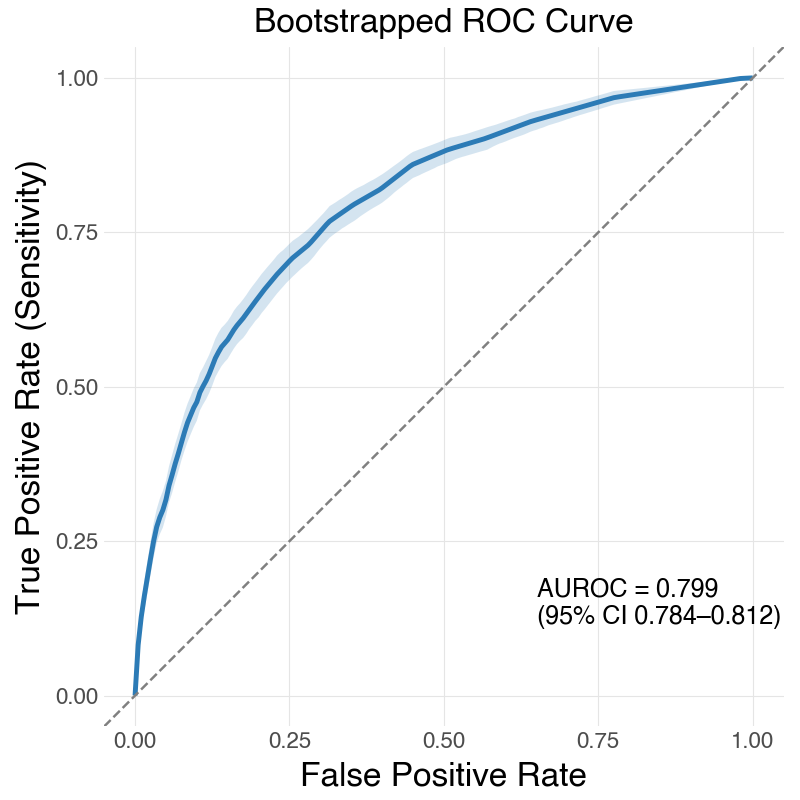

/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 4 x 4 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/pr_curve.png


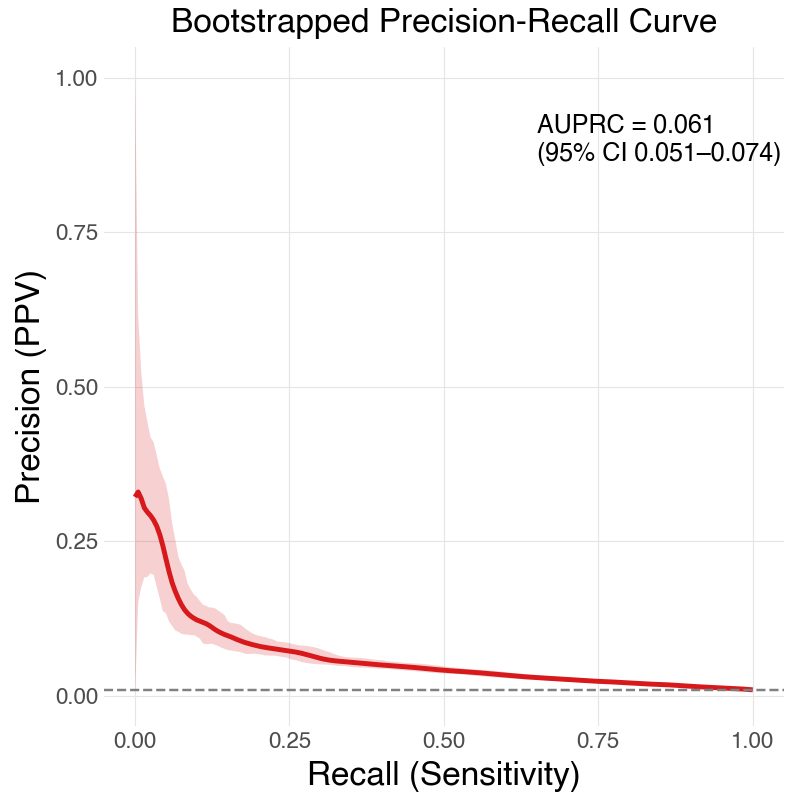

In [29]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score, average_precision_score
from plotnine import (
    ggplot, aes, geom_ribbon, geom_line, geom_abline, annotate,
    labs, theme_minimal, theme, element_text, element_blank, element_line,
    coord_fixed
)

%matplotlib inline

# ============================================================
# 1. Load data
# ============================================================
test_df = pd.read_csv(save_filepath + "outputs/test-preds.csv", index_col=0)

y_true_full = test_df['y_true'].values
y_prob_full = test_df['y_proba'].values

thresholds = np.linspace(0, 1, num=1001)
recall_grid = np.linspace(0, 1, num=201)
fpr_grid = np.linspace(0, 1, num=201)

# ============================================================
# 2. Point estimates on the real (non-resampled) data
#    These are the numbers you report; bootstraps supply the CI.
# ============================================================
auroc_point = roc_auc_score(y_true_full, y_prob_full)
auprc_point = average_precision_score(y_true_full, y_prob_full)

# ============================================================
# 3. Per-bootstrap threshold sweep -> confusion matrix counts
#    Kept for the sensitivity/specificity/PPV-vs-threshold table
#    used elsewhere (e.g. the false-alarm-ratio-vs-sensitivity plot).
# ============================================================
def bootstrap_sample(df, thresholds, index):
    df_sampled = df.sample(frac=1.0, replace=True, random_state=index)
    y_prob = df_sampled['y_proba'].values
    y_true = df_sampled['y_true'].values

    is_pos = y_true == 1
    is_neg = ~is_pos

    preds_pos = y_prob[:, None] >= thresholds[None, :]

    tp = (preds_pos & is_pos[:, None]).sum(axis=0)
    fp = (preds_pos & is_neg[:, None]).sum(axis=0)
    fn = (~preds_pos & is_pos[:, None]).sum(axis=0)
    tn = (~preds_pos & is_neg[:, None]).sum(axis=0)

    return pd.DataFrame({
        'Index': index,
        'Threshold': thresholds,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })

thresh_results = joblib.Parallel(n_jobs=8, verbose=1)(
    joblib.delayed(bootstrap_sample)(test_df, thresholds, index)
    for index in range(1000)
)

thresh_results = pd.concat(thresh_results, ignore_index=True)

# ---- Metrics on the threshold table ----
def safe_div(numerator, denominator):
    return np.where(denominator > 0, numerator / np.where(denominator > 0, denominator, 1), 0.0)

tn, fp, fn, tp = (thresh_results[c].values for c in ['TN', 'FP', 'FN', 'TP'])

thresh_results['Sensitivity'] = safe_div(tp, tp + fn)
thresh_results['Specificity'] = safe_div(tn, tn + fp)
thresh_results['Youden Index'] = thresh_results['Sensitivity'] + thresh_results['Specificity'] - 1
thresh_results['FPR'] = safe_div(fp, tn + fp)
thresh_results['FNR'] = safe_div(fn, tp + fn)
thresh_results['NPV'] = safe_div(tn, fn + tn)
thresh_results['NNS'] = safe_div(fp + tp, tp)

# PPV and Lift are undefined (not zero) when no positive predictions were made.
no_positive_preds = (tp + fp) == 0
thresh_results['PPV'] = np.where(no_positive_preds, np.nan, tp / np.where(no_positive_preds, 1, tp + fp))
thresh_results['Lift'] = thresh_results['PPV'].values / test_df['y_true'].mean()

thresh_results.to_csv(save_filepath + "outputs/thresholds-on-test-set.csv")

# ---- Summarise across bootstraps (NaN-aware, so undefined PPV doesn't distort estimates) ----
thresh_results_summarised = thresh_results.melt(
    id_vars=['Index', 'Threshold'],
    var_name='Metric'
).groupby(['Threshold', 'Metric']).agg(
    estimate=('value', lambda y: np.nanmean(y)),
    lower_conf=('value', lambda y: np.nanpercentile(y, 2.5)),
    upper_conf=('value', lambda y: np.nanpercentile(y, 97.5))
).reset_index()

thresh_results_summarised = thresh_results_summarised.pivot_table(
    index='Threshold',
    columns='Metric',
    values=['estimate', 'lower_conf', 'upper_conf']
).reset_index()

thresh_results_summarised.columns = [
    '_'.join(col).strip('_') if col[1] else col[0]
    for col in thresh_results_summarised.columns
]

thresh_results_summarised.to_csv(save_filepath + "outputs/thresholds-on-test-set-summarised.csv")

# ============================================================
# 4. Bootstrapped ROC / PR curves, correctly aligned
#    Curves are interpolated onto a COMMON grid of FPR (ROC) /
#    recall (PR) per bootstrap, THEN aggregated across bootstraps.
#    This avoids mixing incomparable points across bootstraps that
#    happen to share a threshold but not a recall/FPR.
# ============================================================
def bootstrap_curves(df, thresholds, fpr_grid, recall_grid, index):
    df_sampled = df.sample(frac=1.0, replace=True, random_state=index)
    y_prob = df_sampled['y_proba'].values
    y_true = df_sampled['y_true'].values

    is_pos = y_true == 1
    is_neg = ~is_pos
    preds_pos = y_prob[:, None] >= thresholds[None, :]

    tp = (preds_pos & is_pos[:, None]).sum(axis=0)
    fp = (preds_pos & is_neg[:, None]).sum(axis=0)
    fn = (~preds_pos & is_pos[:, None]).sum(axis=0)
    tn = (~preds_pos & is_neg[:, None]).sum(axis=0)

    sens = np.where((tp + fn) > 0, tp / np.where((tp + fn) > 0, tp + fn, 1), np.nan)
    fpr  = np.where((fp + tn) > 0, fp / np.where((fp + tn) > 0, fp + tn, 1), np.nan)
    ppv  = np.where((tp + fp) > 0, tp / np.where((tp + fp) > 0, tp + fp, 1), np.nan)

    # --- ROC: interpolate TPR onto common FPR grid ---
    order_roc = np.argsort(fpr)
    fpr_sorted, sens_for_roc = fpr[order_roc], sens[order_roc]
    valid_roc = ~np.isnan(fpr_sorted) & ~np.isnan(sens_for_roc)
    tpr_interp = np.interp(fpr_grid, fpr_sorted[valid_roc], sens_for_roc[valid_roc])
    auroc = np.trapz(tpr_interp, fpr_grid)

    # --- PR: interpolate precision onto common recall grid ---
    # Undefined-precision points (no positive predictions) are dropped, not zero-filled.
    order_pr = np.argsort(sens)
    sens_sorted, ppv_for_pr = sens[order_pr], ppv[order_pr]
    valid_pr = ~np.isnan(sens_sorted) & ~np.isnan(ppv_for_pr)
    ppv_interp = np.interp(recall_grid, sens_sorted[valid_pr], ppv_for_pr[valid_pr])
    auprc = np.trapz(ppv_interp, recall_grid)

    return tpr_interp, ppv_interp, auroc, auprc

curve_results = joblib.Parallel(n_jobs=8, verbose=1)(
    joblib.delayed(bootstrap_curves)(test_df, thresholds, fpr_grid, recall_grid, index)
    for index in range(1000)
)

tpr_matrix = np.array([r[0] for r in curve_results])   # (1000, len(fpr_grid))
ppv_matrix = np.array([r[1] for r in curve_results])   # (1000, len(recall_grid))
auroc_boot = np.array([r[2] for r in curve_results])
auprc_boot = np.array([r[3] for r in curve_results])

roc_plot_df = pd.DataFrame({
    'FPR': fpr_grid,
    'TPR_est': tpr_matrix.mean(axis=0),
    'TPR_lc': np.percentile(tpr_matrix, 2.5, axis=0),
    'TPR_uc': np.percentile(tpr_matrix, 97.5, axis=0)
})

pr_plot_df = pd.DataFrame({
    'Recall': recall_grid,
    'Precision_est': ppv_matrix.mean(axis=0),
    'Precision_lc': np.percentile(ppv_matrix, 2.5, axis=0),
    'Precision_uc': np.percentile(ppv_matrix, 97.5, axis=0)
})

auroc_lc, auroc_uc = np.percentile(auroc_boot, [2.5, 97.5])
auprc_lc, auprc_uc = np.percentile(auprc_boot, [2.5, 97.5])

roc_plot_df.to_csv(save_filepath + "outputs/roc-curve-bootstrapped.csv")
pr_plot_df.to_csv(save_filepath + "outputs/pr-curve-bootstrapped.csv")



# ============================================================
# 5. Plots
# ============================================================

roc_plot_df = pd.read_csv(save_filepath + "outputs/roc-curve-bootstrapped.csv")
pr_plot_df = pd.read_csv(save_filepath + "outputs/pr-curve-bootstrapped.csv")
p_roc = (
    ggplot(roc_plot_df, aes(x='FPR', y='TPR_est', ymin='TPR_lc', ymax='TPR_uc'))
    + geom_ribbon(alpha=0.2, fill='#2c7bb6')
    + geom_line(color='#2c7bb6', size=1)
    + geom_abline(intercept=0, slope=1, linetype='dashed', color='gray', size=0.5)
    + annotate('text', x=0.65, y=0.15,
               label=f'AUROC = {auroc_point:.3f}\n(95% CI {auroc_lc:.3f}\u2013{auroc_uc:.3f})',
               size=9, ha='left')
    + labs(title='Bootstrapped ROC Curve', x='False Positive Rate', y='True Positive Rate (Sensitivity)')
    + coord_fixed(ratio=1)
    + theme_minimal(base_size=10)
    + theme(
        figure_size=(4, 4),
        plot_title=element_text(size=12, weight='bold'),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(size=0.4),
        axis_title=element_text(size=12, weight='bold'),
    )
)
p_roc.save(save_filepath + "outputs/roc_curve.png", dpi=300)
p_roc.show()

p_pr = (
    ggplot(pr_plot_df, aes(x='Recall', y='Precision_est', ymin='Precision_lc', ymax='Precision_uc'))
    + geom_ribbon(alpha=0.2, fill='#d7191c')
    + geom_line(color='#d7191c', size=1)
    + geom_abline(intercept=y_true_full.mean(), slope=0, linetype='dashed', color='gray', size=0.5)
    + annotate('text', x=0.65, y=0.9,
               label=f'AUPRC = {auprc_point:.3f}\n(95% CI {auprc_lc:.3f}\u2013{auprc_uc:.3f})',
               size=9, ha='left')
    + labs(title='Bootstrapped Precision-Recall Curve', x='Recall (Sensitivity)', y='Precision (PPV)')
    + coord_fixed(ratio=1)
    + theme_minimal(base_size=10)
    + theme(
        figure_size=(4, 4),
        plot_title=element_text(size=12, weight='bold'),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(size=0.4),
        axis_title=element_text(size=12, weight='bold'),
    )
)
p_pr.save(save_filepath + "outputs/pr_curve.png", dpi=300)
p_pr.show()

What are the metrics we care about? We want to minimise the number of false alarms (i.e. minimise FPR) while maximising the fraction of cases that are actually caught (i.e. maximise TPR).
Alternatively we can maximise the value of the signal (maximise PPV) while minimising false negative rate (fraction of people who are missed).

This is of course assuming a 2-bucket scheme.
But for a single threshold, this is what we end up with. What is the optimal threshold for this?

Next we'd have to think about having, essentially, multiple risk buckets.

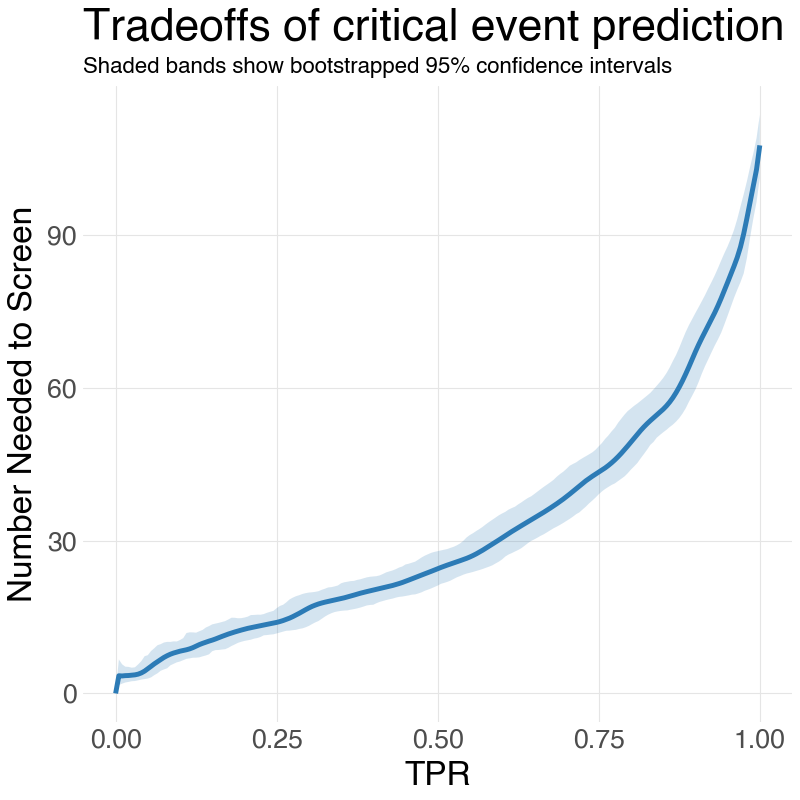

,Sensitivity,estimate,lower_conf,upper_conf
0,0.000,0.000000,0.000000,0.000000
1,0.005,3.470795,1.628463,6.674100
2,0.010,3.428615,1.908928,5.727013
3,0.015,3.493382,2.139316,5.257091
4,0.020,3.517489,2.258832,5.209940
...,...,...,...,...
196,0.980,93.366698,85.557293,100.644862
197,0.985,96.569522,89.651867,103.485882
198,0.990,99.790342,93.331984,106.135964
199,0.995,103.011949,96.611582,109.147792


In [30]:
%matplotlib inline

import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_ribbon, geom_line,
    labs, theme_minimal, theme,
    element_text, element_blank, element_line
)

# Load raw per-bootstrap, per-threshold results (NOT the summarised version —
# we need each bootstrap's individual curve to interpolate correctly).
thresh_results = pd.read_csv(save_filepath + "outputs/thresholds-on-test-set.csv", index_col=0)


def interpolate_metric_pair(df, x_metric, y_metric, x_grid):
    """
    For each bootstrap, sort by x_metric and interpolate y_metric onto a
    common x_grid. Returns a matrix of shape (n_bootstraps, len(x_grid)).
    """
    curves = []
    for idx, g in df.groupby('Index'):
        g = g.sort_values(x_metric)
        x_vals = g[x_metric].values
        y_vals = g[y_metric].values

        valid = ~np.isnan(x_vals) & ~np.isnan(y_vals)
        x_vals, y_vals = x_vals[valid], y_vals[valid]

        # np.interp requires x_vals ascending and unique-ish; sort handles ascending.
        # Where x_metric has duplicate values (flat regions), interp just uses the
        # first match in sorted order, which is fine for monotonic-ish metrics.
        y_interp = np.interp(x_grid, x_vals, y_vals)
        curves.append(y_interp)

    return np.array(curves)  # shape (n_bootstraps, len(x_grid))


def plot_metrics_interpolated(x, y, title, x_name=None, y_name=None,
                               x_grid=None, n_grid=201, fill='#2c7bb6', color='#2c7bb6'):

    if x_grid is None:
        x_grid = np.linspace(0, 1, n_grid)

    y_matrix = interpolate_metric_pair(thresh_results, x, y, x_grid)

    plot_df = pd.DataFrame({
        x: x_grid,
        'estimate': np.nanmean(y_matrix, axis=0),
        'lower_conf': np.nanpercentile(y_matrix, 2.5, axis=0),
        'upper_conf': np.nanpercentile(y_matrix, 97.5, axis=0)
    })

    p = (
        ggplot(plot_df, aes(x=x, y='estimate', ymin='lower_conf', ymax='upper_conf'))
        + geom_ribbon(alpha=0.2, fill=fill)
        + geom_line(size=1, color=color)
        + labs(
            title=title,
            subtitle='Shaded bands show bootstrapped 95% confidence intervals',
            x=x if x_name is None else x_name,
            y=y if y_name is None else y_name
        )
        + theme_minimal(base_size=12)
        + theme(
            figure_size=(4, 4),
            plot_title=element_text(size=16, weight='bold'),
            plot_subtitle=element_text(size=8),
            panel_grid_minor=element_blank(),
            panel_grid_major=element_line(size=0.4),
            axis_title=element_text(size=12, weight='bold'),
        )
    )

    p.show()
    return plot_df


plot_metrics_interpolated(
    'Sensitivity', 'NNS',
    'Tradeoffs of critical event prediction',
    x_name='TPR',
    y_name='Number Needed to Screen'
)

Explain the chosen XGBoost model's predictions with a SHAP beeswarm plot.

In [ ]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

#Load the fitted XGBoost model, its feature names, and the test split -- all saved together
#by cell 9 in the SAME run, so there's no way for them to drift out of sync with each other
#(unlike reconstructing feature names separately here, which could silently mislabel columns
#if this cell's preprocessing code and the model's training-time code ever diverged).
fitted_models = joblib.load(save_filepath + "outputs/fitted-models.joblib")
xgb_model = fitted_models["xgboost"]
feature_names = fitted_models["feature_names"]
#xgb_model is the sklearn Pipeline built in cell 9; the classifier itself is the "model" step.
xgb_estimator = xgb_model.named_steps["model"]

[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath + "outputs/split.joblib")

#Sanity check: fitted-models.joblib and split.joblib should always be saved together by the
#same run of cell 9, but if an old split.joblib or fitted-models.joblib is loaded alongside a
#newer one (e.g. only one of the two files got overwritten), this catches it immediately
#instead of silently mislabeling every column below.
assert len(feature_names) == X_test.shape[1], (
    f"Feature count mismatch: fitted-models.joblib has {len(feature_names)} feature names but "
    f"X_test (from split.joblib) has {X_test.shape[1]} columns. These two files are likely out "
    f"of sync -- re-run cell 9 (which saves both together) before trusting the plot below."
)

X_test_named = X_test.copy()
X_test_named.columns = feature_names

#SHAP beeswarm plot for the chosen XGBoost model on the held-out test set.
explainer = shap.TreeExplainer(xgb_estimator)
shap_values = explainer.shap_values(X_test_named)

plt.figure()
shap.summary_plot(shap_values, X_test_named, show=False)
plt.tight_layout()
plt.savefig(save_filepath + "outputs/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()